# Diabetes Prediction with SVM

**Classifying diabetes risk using Support Vector Classification (SVC) with kernel optimization**

---

| Detail | Value |
|--------|-------|
| **Dataset** | Pima Indians Diabetes Dataset |
| **Techniques** | SVC, Kernel Trick, StandardScaler, GridSearch, Classification Report |
| **Author** | Ahmed Alnahrawy |



## 1. Setup & Data Loading

Import libraries and load the diabetes dataset.


In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve

In [78]:
df= pd.read_csv('../data/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0,33.6,0.627,50,1
1,1,85,66,29.0,0,26.6,0.351,31,0
2,8,183,64,0.0,0,23.3,0.672,32,1
3,1,89,66,23.0,94,28.1,0.167,21,0
4,0,137,40,35.0,168,43.1,2.288,33,1



## 2. Exploratory Data Analysis

Explore feature distributions, correlations, and class balance.


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               772 non-null    int64  
 1   Glucose                   772 non-null    int64  
 2   BloodPressure             772 non-null    int64  
 3   SkinThickness             770 non-null    float64
 4   Insulin                   772 non-null    int64  
 5   BMI                       765 non-null    float64
 6   DiabetesPedigreeFunction  772 non-null    float64
 7   Age                       772 non-null    int64  
 8   Outcome                   772 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.4 KB


In [80]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,772.000000,772.000000,772.000000,770.000000,772.000000,765.000000,772.000000,772.000000,772.000000
mean,3.830311,120.835492,69.084197,20.563636,79.386010,32.029673,0.471152,33.250000,0.349741
std,3.367035,31.922208,19.311144,15.940371,115.087543,7.803795,0.330623,11.762167,0.477197
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.400000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,24.000000,32.000000,0.370000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,126.250000,36.500000,0.624500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [81]:
df.duplicated().sum()

4

In [82]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               2
Insulin                     0
BMI                         7
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 3. Preprocessing

Handle zero-value features, scale data, and split into train/test sets.


In [83]:
df.dropna()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0,33.6,0.627,50,1
1,1,85,66,29.0,0,26.6,0.351,31,0
2,8,183,64,0.0,0,23.3,0.672,32,1
3,1,89,66,23.0,94,28.1,0.167,21,0
4,0,137,40,35.0,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
767,1,93,70,31.0,0,30.4,0.315,23,0
768,1,126,60,0.0,0,30.1,0.349,47,1
769,1,93,70,31.0,0,30.4,0.315,23,0
770,1,126,60,0.0,0,30.1,0.349,47,1


In [84]:
df['Outcome'].value_counts()

Outcome
0    502
1    270
Name: count, dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

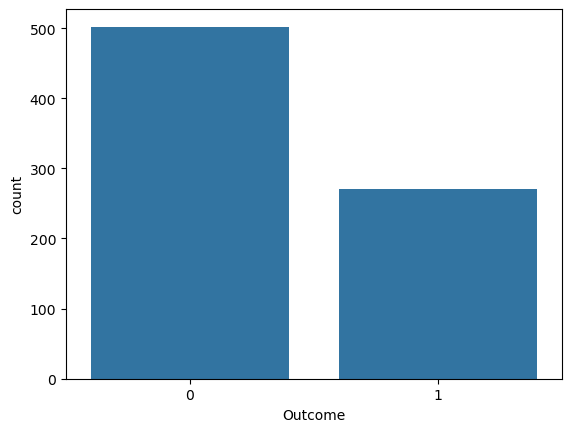

In [85]:
sns.countplot(x= df['Outcome'],data=df)

<Axes: >

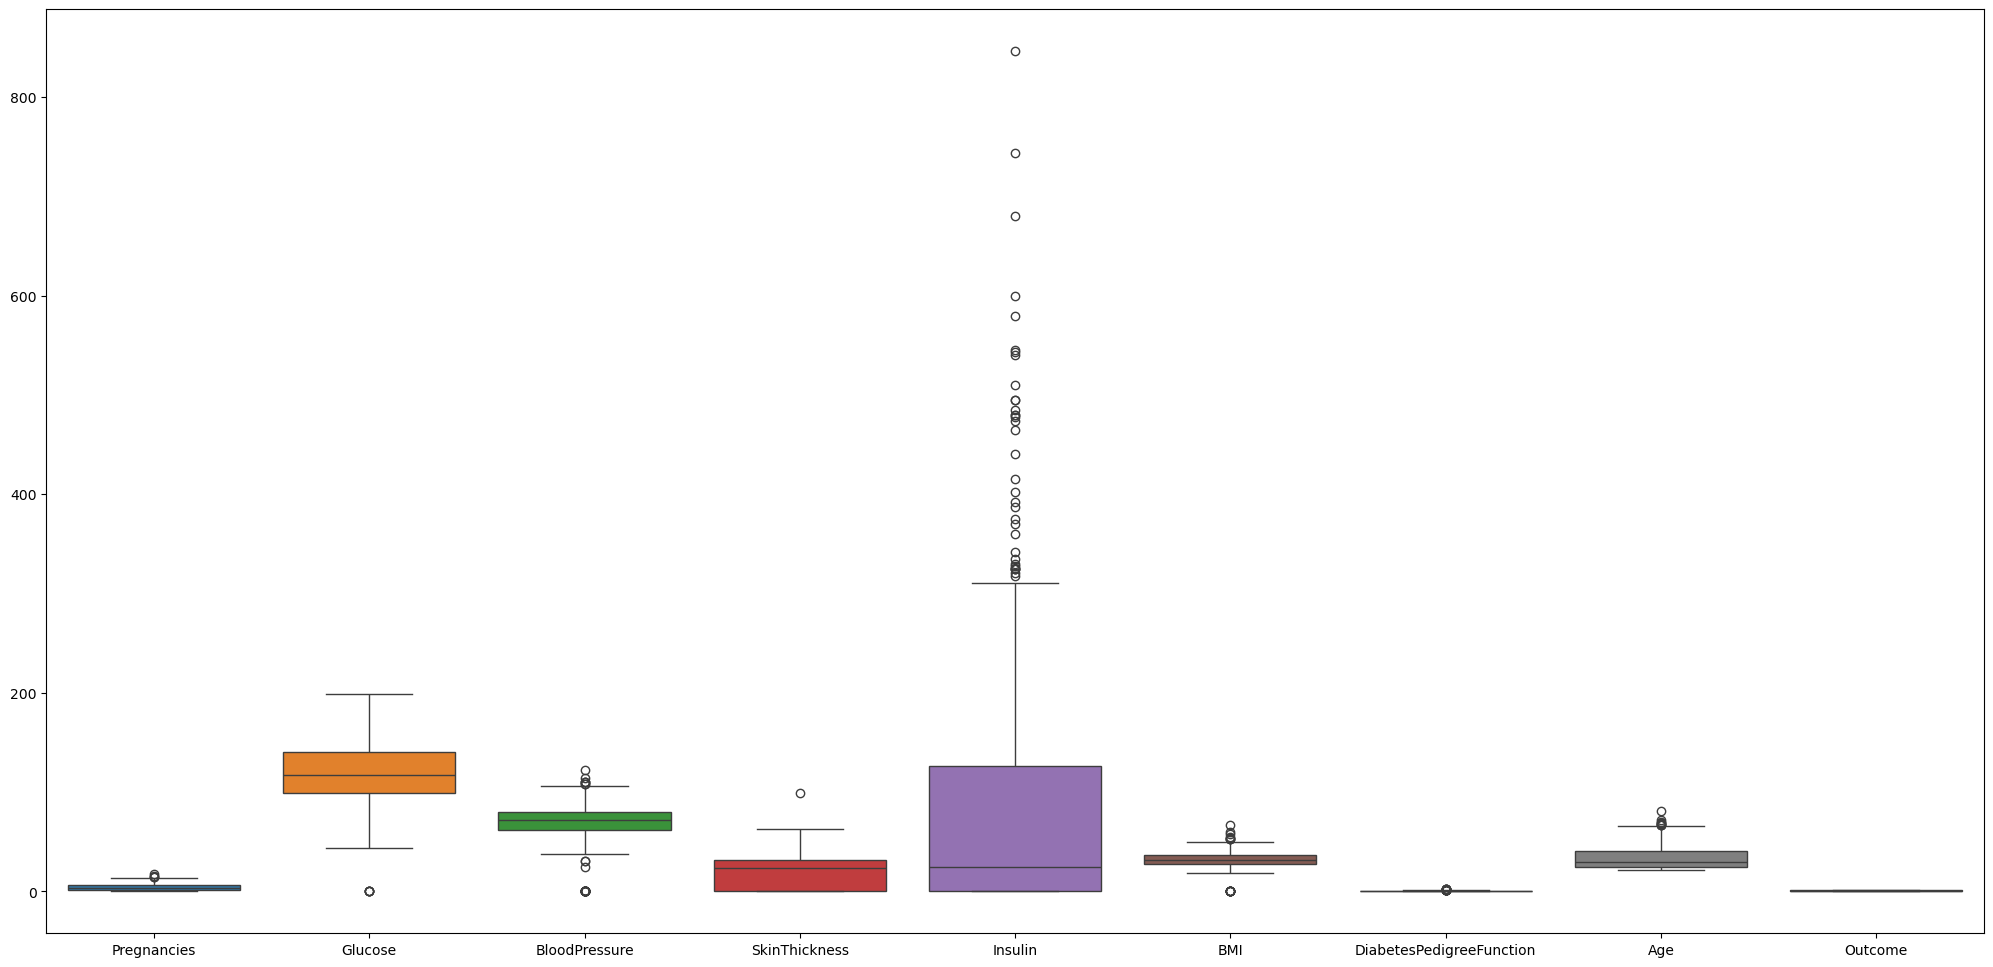

In [86]:
plt.figure(figsize=(25,12))
sns.boxplot(data=df)


## 4. SVM Model Training

Train SVC with different kernels and evaluate classification performance.


<Axes: >

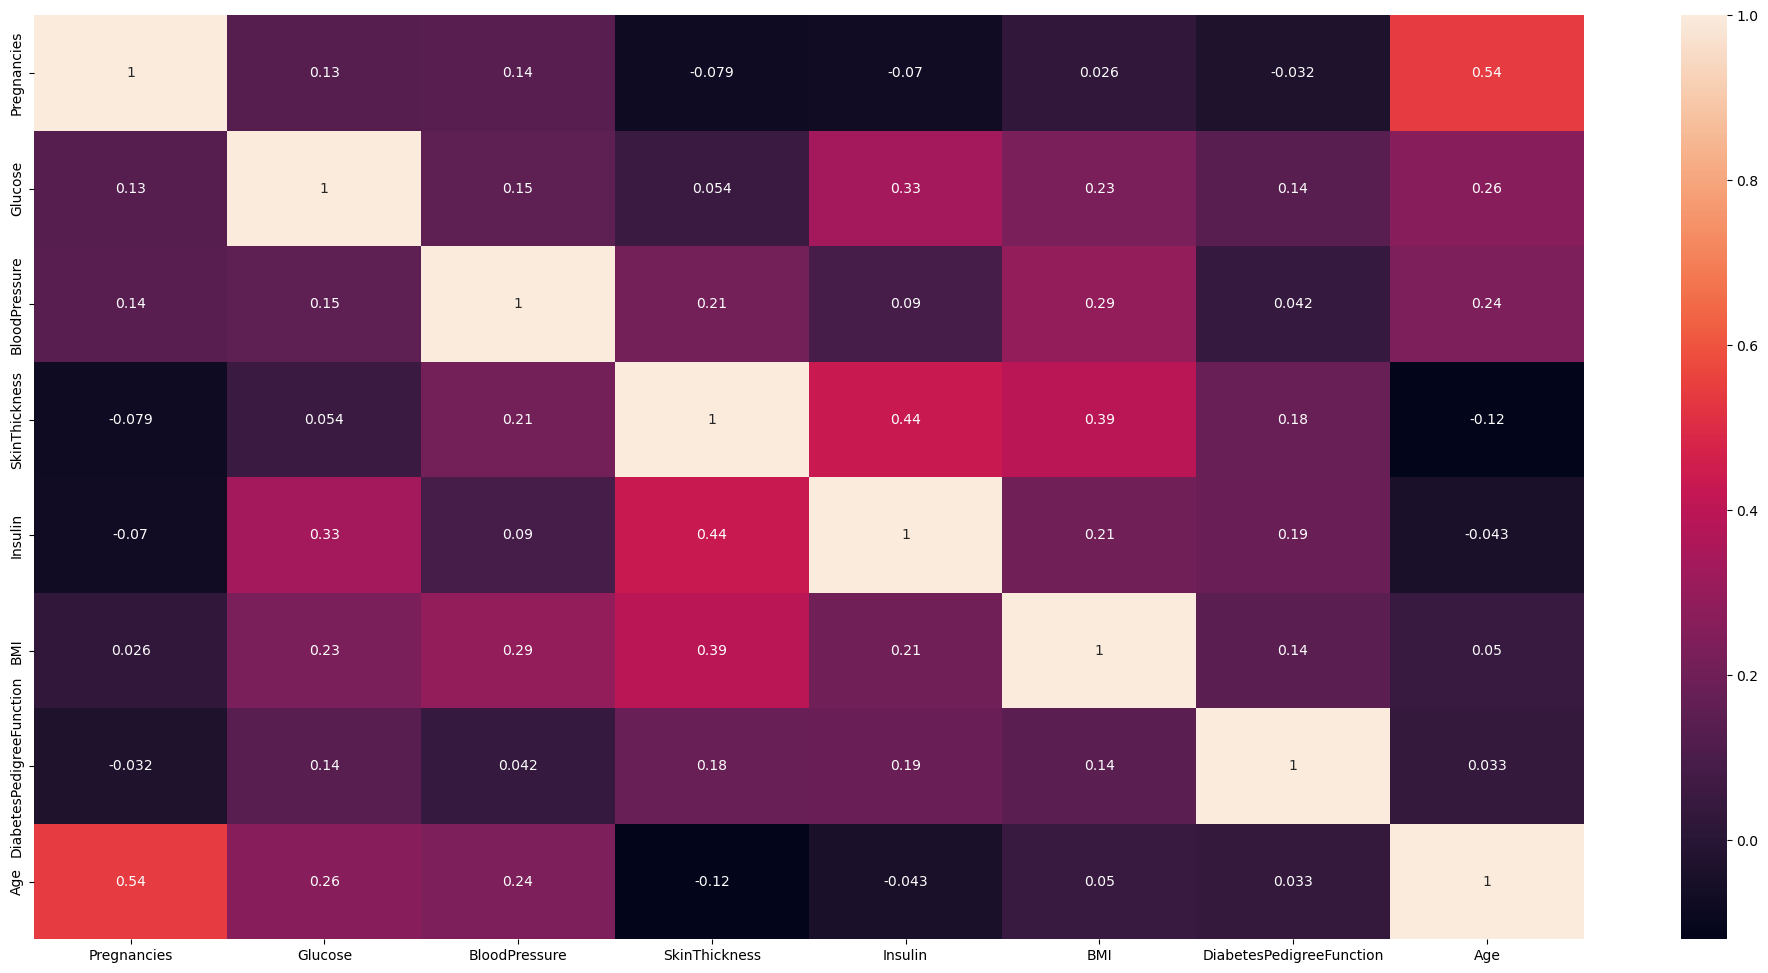

In [87]:
plt.figure(figsize=(25,12))
corr=df.drop("Outcome",axis=1).corr()
sns.heatmap(corr, annot=True)


In [88]:
df['Insulin'] = df['Insulin'].replace(0, np.nan)


for col in ['SkinThickness', 'BMI', 'Insulin']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

df_processed = df.copy()


df_processed.drop_duplicates(inplace=True)


columns_with_zeros_as_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
for col in columns_with_zeros_as_nan:
    df_processed[col] = df_processed[col].replace(0, np.nan)


for col in df_processed.columns:
    if df_processed[col].isnull().any():
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)

Q1_insulin = df_processed['Insulin'].quantile(0)
Q3_insulin = df_processed['Insulin'].quantile(0.75)
IQR_insulin = Q3_insulin - Q3_insulin

lower_bound_insulin = Q1_insulin - 1.5 * IQR_insulin
upper_bound_insulin = Q3_insulin + 1.5 * IQR_insulin

X_scaled = df_processed.drop('Outcome', axis=1)
y_scaled = df_processed['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scaled)


X_scaled_df = pd.DataFrame(X_scaled, columns=df_processed.drop('Outcome', axis=1).columns)


C:\Users\medoc\AppData\Local\Temp\ipykernel_3476\2638050343.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\medoc\AppData\Local\Temp\ipykernel_3476\2638050343.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [89]:

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled_df, y_scaled, test_size=0.2, random_state=42)

In [90]:

svm_model = SVC(kernel='linear', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train_scaled)


y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

Accuracy: 0.7532
Precision: 0.6667
Recall: 0.6182
F1-Score: 0.6415
ROC AUC Score: 0.8233


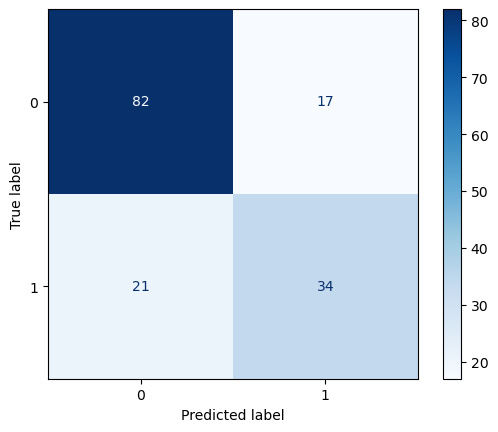

In [91]:

accuracy = accuracy_score(y_test_scaled, y_pred)
precision = precision_score(y_test_scaled, y_pred)
recall = recall_score(y_test_scaled, y_pred)
f1 = f1_score(y_test_scaled, y_pred)
roc_auc = roc_auc_score(y_test_scaled, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")


cm = confusion_matrix(y_test_scaled, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()


---

## Summary

This notebook demonstrated svc, kernel trick, standardscaler, gridsearch, classification report techniques applied to the Pima Indians Diabetes Dataset.

**Author:** Ahmed Alnahrawy | [GitHub](https://github.com/Ahmed-Na7rawy)
